In [46]:
from pathlib import Path

import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# Instead of fetching the dataset again and again , I have simply downloaded the zip folder for the adults dataset whiCH i will be using for this notebooks

In [3]:
BASE_PATH = Path.cwd().parent / "datasets" / "adult"

TRAIN_PATH = BASE_PATH / "adult.data"
TEST_PATH = BASE_PATH / "adult.test"

In [4]:
# Column names from adult.names : 
""" 
age: continuous.
workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
fnlwgt: continuous.
education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
education-num: continuous.
marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
sex: Female, Male.
capital-gain: continuous.
capital-loss: continuous.
hours-per-week: continuous.
native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

"""

columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "salary"
]


In [5]:
# Best practice is to use exceptional handling here but for now just load the training and testing set 
train = pd.read_csv(TRAIN_PATH, header=None, names=columns)
test = pd.read_csv(TEST_PATH, header=None, names=columns, skiprows=1)

# The dataset did not contain the column names but were given to us in a seperate txtfile.
# Also the y column had a corrupt first row which we skip for now.

In [6]:
train.shape

(32561, 15)

In [7]:
test.shape

(16281, 15)

In [8]:
train.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [9]:
test.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K.


In [10]:
train.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
salary            0
dtype: int64

In [11]:
test.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
salary            0
dtype: int64

In [12]:
# For precaution anyways.
train = train.dropna()
test = test.dropna()

# EDA (Compdete dataset)

In [13]:
# Now for further EDA analysis I will concat both the dataset .

In [14]:
df = pd.concat([train,test],axis=0)

In [15]:
# The fnlwgt column does not infuence much to our output so we are gonna drop for now.
df = df.drop(columns=['fnlwgt'])

In [16]:
df.shape # The combined shape

(48842, 14)

In [17]:
df.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [18]:
# A quick initial analysis function 

def examine_dataframe(df):
    print("-"*100)
    print(f'NOTE : Column names will be converted to lower case and trimming all the white spaces.')
    print("-"*100)
    df.columns = [x.lower().strip().replace(" ","_") for x in df.columns]
    print(f"Dataframe shape : {df.shape}")
    print("-"*100)
    print(f"Memory Usage : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print("-"*100)
    print(f"Column Dtypes: \n{df.dtypes.value_counts()}")
    print("-"*100)
    print(f'Quick overview of all columns: ')
    columns_df = pd.DataFrame({
                'column' : df.columns,
                'dtype' : [x for x in df.dtypes],
                '#unique_values' : [df[x].nunique() for x in df.columns],
                '#non_null_values' : df.notna().sum().tolist() ,
                '#null_values' : df.isna().sum().tolist() ,
                '%null_values' : [f'{x:.2f}' for x in ((df.isna().sum()/df.shape[0])*100).to_list()]
                
        })
    return (columns_df)

In [19]:
examine_dataframe(df)

----------------------------------------------------------------------------------------------------
NOTE : Column names will be converted to lower case and trimming all the white spaces.
----------------------------------------------------------------------------------------------------
Dataframe shape : (48842, 14)
----------------------------------------------------------------------------------------------------
Memory Usage : 26.91 MB
----------------------------------------------------------------------------------------------------
Column Dtypes: 
object    9
int64     5
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Quick overview of all columns: 


,column,dtype,#unique_values,#non_null_values,#null_values,%null_values
0,age,int64,74,48842,0,0.00
1,workclass,object,9,48842,0,0.00
2,education,object,16,48842,0,0.00
3,education-num,int64,16,48842,0,0.00
4,marital-status,object,7,48842,0,0.00
5,occupation,object,15,48842,0,0.00
6,relationship,object,6,48842,0,0.00
7,race,object,5,48842,0,0.00
8,sex,object,2,48842,0,0.00
9,capital-gain,int64,123,48842,0,0.00


In [20]:
# Changed the loading method from polars to pandas ---> I saw a huge difference.
# First of many cols were automatically treated as str in polars but here pandas treat them as numeric (int).
# There were empty rows in both train and test set which were not flagged in pandas.
# So we will be sticking to pandas for better interpretibility and inoperability.

In [21]:
# The dataframe contains both numeric and string values together .

# The dataset has a lot of columns with high cardinality (especially categorical).
# Suitable strategy has to be devised to handle each categorical column.

In [22]:
df.sample(5)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
11967,76,Private,HS-grad,9,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,8,United-States,<=50K
9509,61,Self-emp-not-inc,HS-grad,9,Married-civ-spouse,Other-service,Wife,Black,Female,0,0,17,United-States,<=50K
14548,42,Private,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,32,United-States,<=50K.
15120,31,State-gov,Some-college,10,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,38,United-States,<=50K
566,73,Private,5th-6th,3,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,54,United-States,>50K.


In [23]:
# This was just a guess but looking closely we found out that dropping nans was just not enough .
# It was a mere trap , the real missing values hiding beneath have also have a "?" symbol attached .
# There could be other symbolic notations or hidden information in the dataset which we may need to decode.

In [24]:
# We will use regex patterns to search for all the "?" cleanly.

# Define the regex pattern (escaping the ? character)
pattern = r'\?'

# Scan every cell, convert to string, and apply regex search
mask = df.map(lambda cell: bool(re.search(pattern, str(cell)))).any(axis=1)

# 3. Filter the DataFrame
filtered_df = df[mask]


In [25]:
len(filtered_df)
# We have like 3620 rows containg such "?" values .
# We need to replace these values with nan in their place

3620

In [26]:
df = df.replace(r'.*\?.*', np.nan, regex=True) # We flag them as NaN for now

In [27]:
# Now are not actually done with fixing inconsitencies , there may or may not be some other dirty string present in each columns .
# To check this we will perform value_counts() for each column to not only clean the dirty columns but also find suitable strategy for encoding later.

In [28]:
df.head(1)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K


In [29]:
df.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [30]:
for x in df.select_dtypes("object").columns : 
    print(df[x].value_counts())
    print()

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical      

In [43]:
" Evaluation on unique values of each column"

# education : 

# THERE ARE NO dirty string present but we have to group some groups into single groups to reduce redundancy while OneHotEncoding.
# Doing this would not only avoid high cardinality but also would be better for the model and encoding process.
 
# marital-status:
# Similar to the education column ---> Find such grouping strategy for workclass that converts these columns into a few number of classes

# relationship : 
# The column will have a high correlation with marital-status in correlation graph
# We will choose the best out of these columns and remove any one of them.
# Here too we can combine classes to one

# sex:
# there is a weight imbalance present.
# We would need a way to handle this.

# salary 
# there are no typical dirty columns but there are two extra classes with. from prev one.
# Our strategy would be absolutely simple -> Convert these cols to a single class when we use mapping

# country 
# As expected has a high amount of cardinality
# We can use OrdinalEncoding on these values to convert them to integer

' Evaluation on unique values of each column'

In [32]:
# Also there are many categorical columns where we would group some classes into a single group to avoid excess number of columns when we onehotencode.
# Another possible choice would be to just convert these groups to do Ordinal encoding on the cols especially the country column

In [33]:
# Now let's analyze the numeric columns : 

In [34]:
df.select_dtypes('number').corr()

,age,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,0.030940,0.077229,0.056944,0.071558
education-num,0.030940,1.000000,0.125146,0.080972,0.143689
capital-gain,0.077229,0.125146,1.000000,-0.031441,0.082157
capital-loss,0.056944,0.080972,-0.031441,1.000000,0.054467
hours-per-week,0.071558,0.143689,0.082157,0.054467,1.000000


In [35]:
# There are no numeric columns correlated with each other ; a good sign as we want no multilcollinearity between the columns.
# Later we will do a VIF test to make sure there is actually no correlation.

In [36]:
df.select_dtypes('number').describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,1079.067626,87.502314,40.422382
std,13.710510,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [37]:
# The age and education-num column seems reasonable for now .
# But the columns capital gain and and capital loss seems a bit suspicious .
# These two columns are completely left skewed from the percentile displayed.
#  Also the hours-per-week column seems a bit skewed as well.
# For more insight we will plot the distributions graphs.

In [38]:
def get_numeric_continous_evaluation(df,numeric_continous_columns):
    for x in numeric_continous_columns:
        print(f'--->{x}<---\n')
        print(f'The Description of the column : \n{df[x].describe()}\n')
        print(f'The Skewness of the column : {df[x].skew():.2f}')
        print(f'The Kurtosis of the column : {df[x].kurt():.2f}\n')

        data = df[x]
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - (1.5*IQR)
        upper_bound = Q3 + (1.5*IQR)
        no_of_outlier = ((df[x] > upper_bound ) | (df[x] < lower_bound )).sum()
        percentage_outlier = no_of_outlier/len(df)*100

        print(f'{'='*50}IQR{'='*50}')
        print(f'The Lower bound : {lower_bound:.2f}')
        print(f'The Upper bound : {upper_bound:.2f}')
        print(f'The Number of outlier for this column by IQR : {no_of_outlier}')
        print(f'The Percentage of outlier for this column by IQR : {percentage_outlier}')
        print(f'='*103)

        print(f'The Graphical Analysis : \n')

        figure , axes = plt.subplots(1,3,figsize=(14,5))

        sns.histplot(
                        data = df,
                        x = x,
                        ax = axes[0],
                        color = "#D93A3A"
        )
        axes[0].set_title(f'Histplot of {x}')

        sns.boxplot(
                        data = df,
                        y = x,
                        ax = axes[1],
                        color = "#B22A2A"
        )
        axes[1].set_title(f'Boxplot of {x}')

        sns.kdeplot(
                        data = df,
                        x = x,
                        ax = axes[2],
                        color = "#A81010"
        )
        axes[2].set_title(f'Kdeplot of {x}')

        plt.tight_layout()
        plt.grid()
        plt.show()

--->age<---

The Description of the column : 
count    48842.000000
mean        38.643585
std         13.710510
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

The Skewness of the column : 0.56
The Kurtosis of the column : -0.18

==================================================IQR==================================================
The Lower bound : -2.00
The Upper bound : 78.00
The Number of outlier for this column by IQR : 216
The Percentage of outlier for this column by IQR : 0.4422423324188199
The Graphical Analysis : 



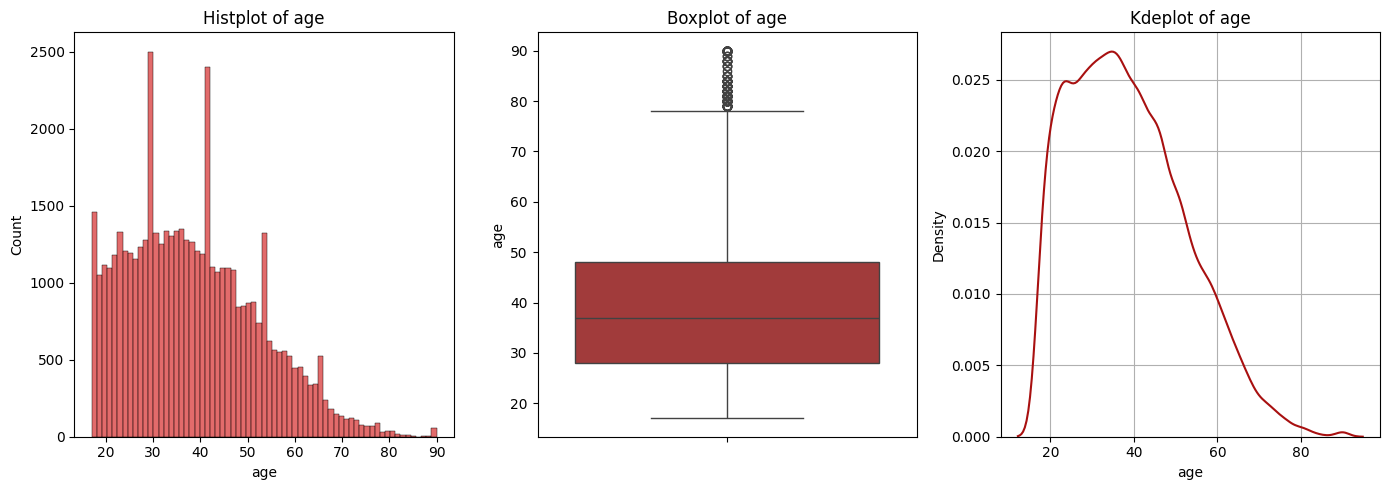

--->education-num<---

The Description of the column : 
count    48842.000000
mean        10.078089
std          2.570973
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: education-num, dtype: float64

The Skewness of the column : -0.32
The Kurtosis of the column : 0.63

==================================================IQR==================================================
The Lower bound : 4.50
The Upper bound : 16.50
The Number of outlier for this column by IQR : 1794
The Percentage of outlier for this column by IQR : 3.6730682609229763
The Graphical Analysis : 



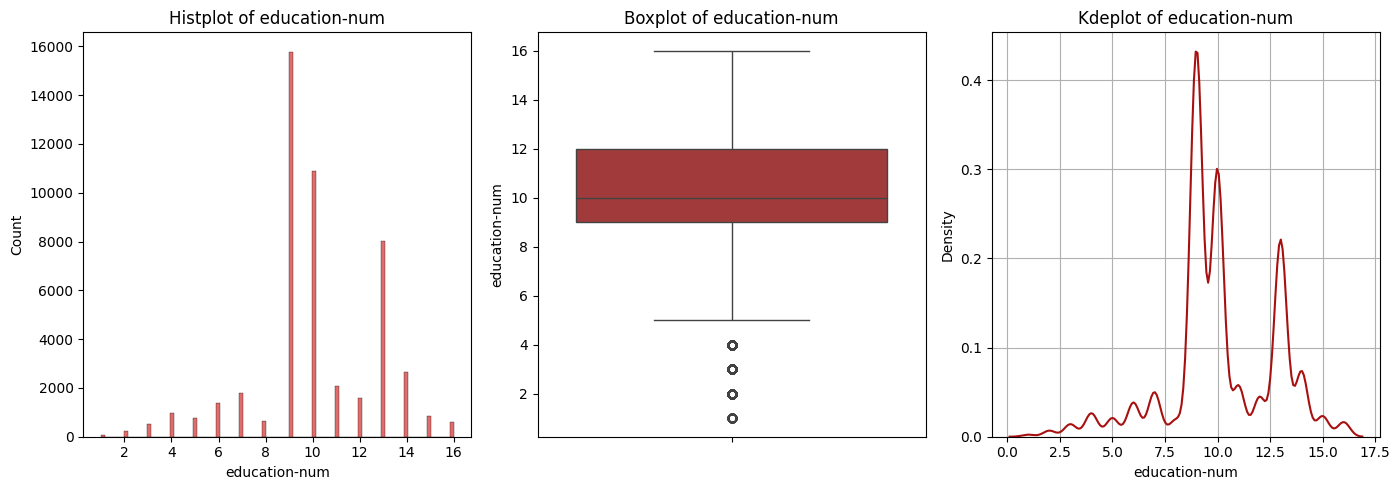

--->capital-gain<---

The Description of the column : 
count    48842.000000
mean      1079.067626
std       7452.019058
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64

The Skewness of the column : 11.89
The Kurtosis of the column : 152.69

==================================================IQR==================================================
The Lower bound : 0.00
The Upper bound : 0.00
The Number of outlier for this column by IQR : 4035
The Percentage of outlier for this column by IQR : 8.261332459768232
The Graphical Analysis : 



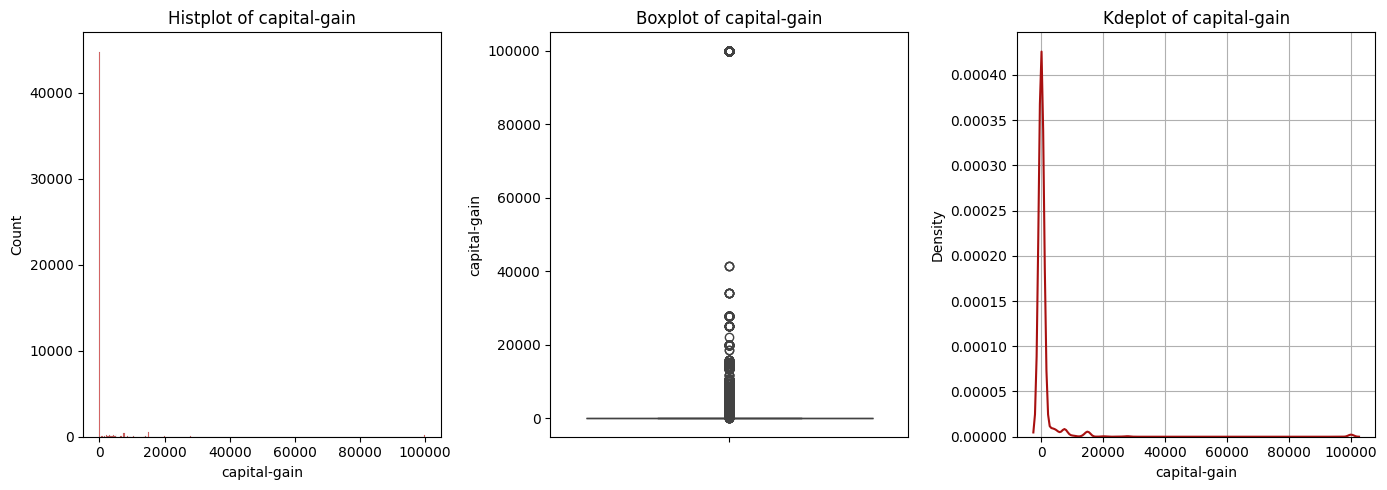

--->capital-loss<---

The Description of the column : 
count    48842.000000
mean        87.502314
std        403.004552
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64

The Skewness of the column : 4.57
The Kurtosis of the column : 20.01

==================================================IQR==================================================
The Lower bound : 0.00
The Upper bound : 0.00
The Number of outlier for this column by IQR : 2282
The Percentage of outlier for this column by IQR : 4.672208345276607
The Graphical Analysis : 



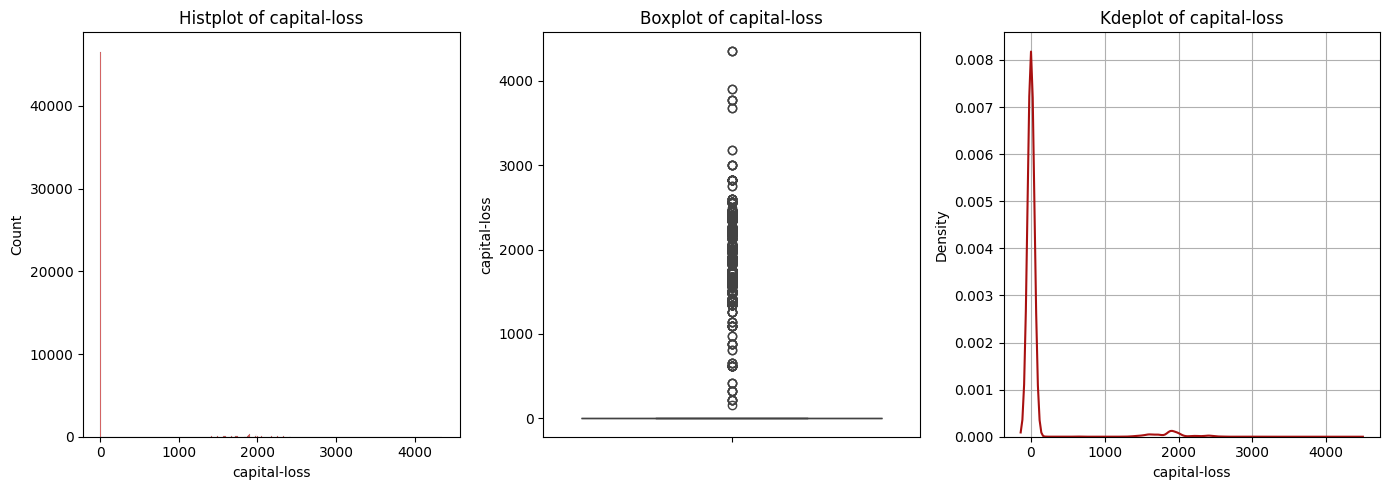

--->hours-per-week<---

The Description of the column : 
count    48842.000000
mean        40.422382
std         12.391444
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64

The Skewness of the column : 0.24
The Kurtosis of the column : 2.95

==================================================IQR==================================================
The Lower bound : 32.50
The Upper bound : 52.50
The Number of outlier for this column by IQR : 13496
The Percentage of outlier for this column by IQR : 27.631956103353673
The Graphical Analysis : 



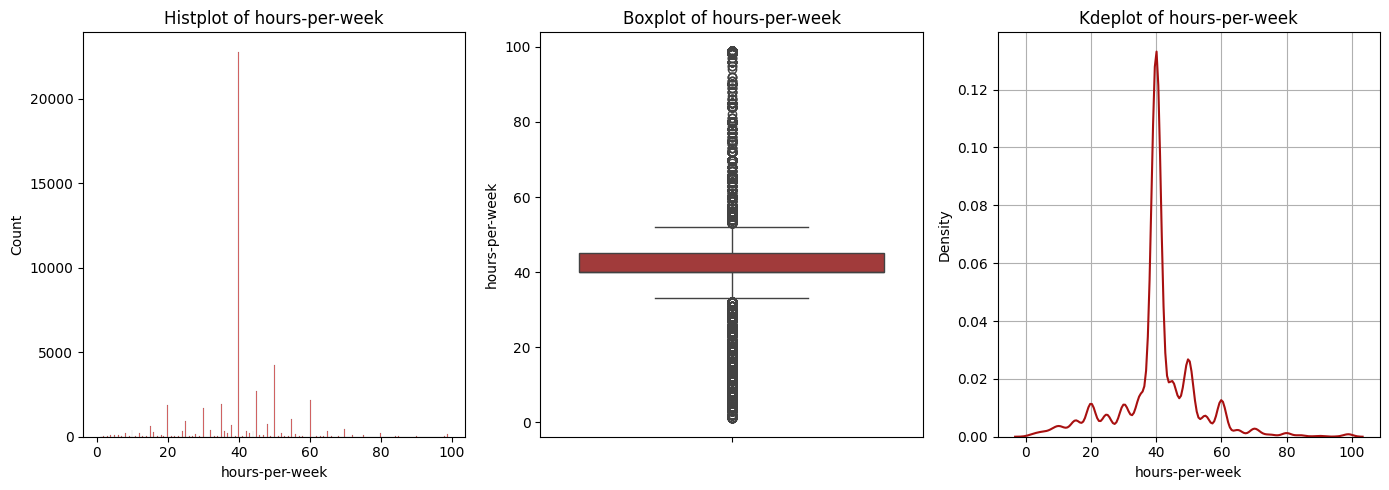

In [39]:
get_numeric_continous_evaluation(df,df.select_dtypes('number').columns)

In [41]:
df.select_dtypes("number")

,age,education-num,capital-gain,capital-loss,hours-per-week
0,39,13,2174,0,40
1,50,13,0,0,13
2,38,9,0,0,40
3,53,7,0,0,40
4,28,13,0,0,40
...,...,...,...,...,...
16276,39,13,0,0,36
16277,64,9,0,0,40
16278,38,13,0,0,50
16279,44,13,5455,0,40


In [42]:
# This function shows us clearly that our assumptions were right and even reveals many new patterns.

' Devising Strategies for the numeric columns '

# age
#   As expected our column is right skewed , this is totally a normal behaviour.
#   Possible strategies to handle this is using bins ---> If we are using linear algorithms or leave it as it is if we are using trees.

# education num
#   This is a categorical like column but already encoded into numeric integers.
#   This column must be left as it is .

# capital-gain,capital-loss
#   Both of these columns are heavily right skewed .
#   There is a peak at a certain position ---> Meaning we can use cutting if we are dealing with linear models.
#   For trees leave it as it is , cause the classifier will find the split appearently.

# hours-per-week
#   This is also an integer column.
#   There is a spike at 40 indicating that we can make a new column upon this which will be a binary questions to answer is value = 40 ?
#   This will work well for linear models and may improve the performance of tree models.

' Devising Strategies for the numeric columns '

In [44]:
# Our next strategy woud be applying VIF for the numeric columns to truly look for dependencies

In [47]:
# Then we also do VIF test to see how each variable can or cannot be predicted by every other variables 
# Ranges from 0 - 5 can be tolerated , till or above ten means there is a huge correlation between this feature and other cols
# The actual range is from 1 - inf



X = df.select_dtypes('number')

X_with_const = add_constant(X)

vif_data = pd.DataFrame()
vif_data["features"] = X_with_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_with_const.values, i) 
    for i in range(X_with_const.shape[1])
]

vif_data = vif_data[vif_data["features"] != 'const']
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print(vif_data)


         features       VIF
0   education-num  1.041277
1  hours-per-week  1.031481
2    capital-gain  1.027722
3    capital-loss  1.013638
4             age  1.013606


In [48]:
# No problems at all